In [3]:
import os, sys
sys.path.insert(0, "/home/dm/Dibyendu/Papers/PathResolvedJCTC/data/NoteBooks/Scripts")
import numpy as np
import matplotlib.pyplot as plt
from openmm import unit
from muller_brown import MullerBrownPotential
from path_gennie import PathGennieMD
from principle_curve import PrincipalCurve
from ensemblerefiner import EnsemblePathRefinerFast
from pathcv import PathCV

In [4]:
def drive_along_path(num_paths=3, path_cv = None,
                     sim = None, start_pos = None, TEMP = 300.0, tau1 = 5, tau2 = 5, max_trial = 15, max_cycle = 5000, tol_target = 0.02, sigma = 0.001, mode = "target", hybrid_switch_index = 0, hybrid_switch_value = 0.5,
                     reset_rate_r = 0.0):
    ensemble = []

    # Custom projection for PathGennie
    # We want to maximize s(x) while keeping z(x) small.
    # Let's project to 1D: modified progress
    def target_pathcv_proj(pos, **kwargs):
        path_cv = kwargs['path_cv']
        cv = pos[0, :2] / 10.0
        s, z = path_cv.compute(cv.reshape(-1, 2))
        return np.array([s, z])

    def convergence_fn(pos, **kwargs):
        path_cv = kwargs['path_cv']
        cv = target_pathcv_proj(pos, path_cv = path_cv)
        # return np.abs(cv[0] - 1.0) < 0.07

        return (
            np.abs(cv[0] - 1.0) < 0.001
            and np.abs(cv[1] - 0.0) < 0.05
        )

    for i in range(num_paths):
        print(f"  Generating ensemble path {i+1}/{num_paths}...")
        pg = PathGennieMD(
            simulation=sim,
            projection_fn=target_pathcv_proj,
            projection_args = {'path_cv':path_cv},
            mode=mode,
            target_projection=np.array([1.0, 0.0]), # Target s = 1.0
            convergence_fn=convergence_fn,
            convergence_args = {'path_cv':path_cv},
            temperature=TEMP,
            sigma=sigma
        )
        traj, _ = pg.run(
            initial_pos=start_pos,
            tau1=tau1,
            tau2=tau2,
            max_trial=max_trial,
            max_cycle=max_cycle,
            save_freq=1,
            verbosity=1,
            reset_rate_r=reset_rate_r,
        )
        ensemble.append(traj[:, 0, :2] / 10.0)
    return ensemble

In [5]:
## Params and setup
TEMP = 300.0
SIGMA = 0.1  # Probabilistic selection temperature
mb = MullerBrownPotential(energy_scale=1.0, temperature=TEMP, friction=10.0, step_size=0.002, mass=10.0)
sim = mb.create_simulation()

start_pos = np.array([[0.623, 0.028, 0.0]]) * unit.nanometer
target_cv = np.array([-0.558, 1.442])  # Basin A in nm

def projection_fn(pos, **kwargs):
    return pos[0, :2] / 10.0  # angstrom to nm

def convergence_fn(pos, **kwargs):
    x, y = pos[0, 0] / 10.0, pos[0, 1] / 10.0
    return np.sqrt((x - target_cv[0])**2 + (y - target_cv[1])**2) < 0.15

In [6]:
pc = PrincipalCurve(
        n_images=500,
        lam=0.1,
        n_iter=50,
        tol=1e-5,
        verbose=False)
refiner = EnsemblePathRefinerFast(hidden_dim=512, device="cuda:0")

def pathRepresentative(ensembles, start = None, end = None):

    smooth_paths = []
    for i in range(len(ensembles)):
        path = pc.fit(ensembles[i].reshape(-1, 2))
        smooth_paths.append(path.reshape(-1, 1, 2))

    refiner = EnsemblePathRefinerFast(hidden_dim=512, device="cuda:0")
    # 3. Fit the model to your trajectory list

    refiner.fit(
        trajectories=smooth_paths[:],
        epochs=5000,
        start=start,
        end=end,
        lr=5e-4,
        patience=50,
        smoothness_weight=1e-5,
        consensus_mode="mean",
        verbosity=True,
    )

    return refiner.transform(n_points=750)

print("Generating initial rough path...")
pg_init = PathGennieMD(
    simulation=sim,
    projection_fn=projection_fn,
    mode="target",
    target_projection=target_cv,
    convergence_fn=convergence_fn,
    temperature=TEMP,
    sigma=SIGMA
)
initial_paths = []
for i in range(5):
    print(f"Trial {i+1}/5")
    traj0, _ = pg_init.run(
        initial_pos=start_pos,
        tau1=5,       # exploration steps
        tau2=2,        # extension steps
        max_trial=20,
        max_cycle=5000,
        save_freq=1,
        verbosity=0
    )
    path0_cv = traj0[:, 0, :2] / 10.0  # (N, 2) in nm
    print(f"Initial path generated with {len(path0_cv)} frames.")
    initial_paths.append(path0_cv)

## First iteration of refinement to get a better path representative
start = np.array([[0.623, 0.028]], dtype=np.float32)
end = np.array([[-0.558, 1.442]], dtype=np.float32)
initial_rep =  pathRepresentative(initial_paths, start = start, end = end)


Generating initial rough path...
Trial 1/5
Initial path generated with 157 frames.
Trial 2/5
Initial path generated with 158 frames.
Trial 3/5
Initial path generated with 158 frames.
Trial 4/5
Initial path generated with 155 frames.
Trial 5/5
Initial path generated with 169 frames.
Epoch     0 | Loss 5.161e-03 | Data 5.161e-03 | Smooth 1.283e-11
Epoch   200 | Loss 3.174e-04 | Data 3.174e-04 | Smooth 1.399e-09
Epoch   400 | Loss 1.983e-04 | Data 1.983e-04 | Smooth 5.403e-09
Epoch   600 | Loss 1.637e-04 | Data 1.637e-04 | Smooth 1.132e-08
Epoch   800 | Loss 1.459e-04 | Data 1.459e-04 | Smooth 2.107e-08
Epoch  1000 | Loss 1.335e-04 | Data 1.335e-04 | Smooth 3.319e-08
Epoch  1200 | Loss 1.263e-04 | Data 1.263e-04 | Smooth 4.649e-08
Epoch  1400 | Loss 1.209e-04 | Data 1.209e-04 | Smooth 6.205e-08
Epoch  1600 | Loss 1.166e-04 | Data 1.166e-04 | Smooth 7.968e-08
Early stopping at epoch 1662


In [7]:
pc = PrincipalCurve(
        n_images=500,
        lam=0.1,
        n_iter=50,
        tol=1e-5,
        verbose=False)
refiner = EnsemblePathRefinerFast(hidden_dim=512, device="cuda:0")

def pathRepresentative(ensembles, start = None, end = None):

    smooth_paths = []
    for i in range(len(ensembles)):
        path = pc.fit(ensembles[i].reshape(-1, 2))
        smooth_paths.append(path.reshape(-1, 1, 2))

    refiner = EnsemblePathRefinerFast(hidden_dim=512, device="cuda:0")
    # 3. Fit the model to your trajectory list

    refiner.fit(
        trajectories=smooth_paths[:],
        epochs=5000,
        start=start,
        end=end,
        lr=5e-4,
        patience=50,
        smoothness_weight=1e-5,
        consensus_mode="mean",
        verbosity=True,
    )

    return refiner.transform(n_points=750)

In [8]:
print("Generating initial rough path...")
pg_init = PathGennieMD(
    simulation=sim,
    projection_fn=projection_fn,
    mode="target",
    target_projection=target_cv,
    convergence_fn=convergence_fn,
    temperature=TEMP,
    sigma=SIGMA
)
initial_paths = []
for i in range(5):
    print(f"Trial {i+1}/5")
    traj0, _ = pg_init.run(
        initial_pos=start_pos,
        tau1=5,       # exploration steps
        tau2=2,        # extension steps
        max_trial=20,
        max_cycle=5000,
        save_freq=1,
        verbosity=0
    )
    path0_cv = traj0[:, 0, :2] / 10.0  # (N, 2) in nm
    print(f"Initial path generated with {len(path0_cv)} frames.")
    initial_paths.append(path0_cv)

## First iteration of refinement to get a better path representative
start = np.array([[0.623, 0.028]], dtype=np.float32)
end = np.array([[-0.558, 1.442]], dtype=np.float32)
initial_rep =  pathRepresentative(initial_paths, start = start, end = end)


Generating initial rough path...
Trial 1/5
Initial path generated with 162 frames.
Trial 2/5
Initial path generated with 153 frames.
Trial 3/5
Initial path generated with 166 frames.
Trial 4/5
Initial path generated with 168 frames.
Trial 5/5
Initial path generated with 158 frames.
Epoch     0 | Loss 5.052e-03 | Data 5.052e-03 | Smooth 2.441e-12
Epoch   200 | Loss 4.853e-04 | Data 4.853e-04 | Smooth 3.000e-09
Epoch   400 | Loss 3.382e-04 | Data 3.382e-04 | Smooth 1.062e-08
Epoch   600 | Loss 2.840e-04 | Data 2.840e-04 | Smooth 2.058e-08
Epoch   800 | Loss 2.576e-04 | Data 2.576e-04 | Smooth 3.260e-08
Epoch  1000 | Loss 2.386e-04 | Data 2.386e-04 | Smooth 4.603e-08
Epoch  1200 | Loss 2.231e-04 | Data 2.231e-04 | Smooth 6.229e-08
Epoch  1400 | Loss 2.113e-04 | Data 2.113e-04 | Smooth 8.121e-08
Epoch  1600 | Loss 2.017e-04 | Data 2.017e-04 | Smooth 1.038e-07
Epoch  1800 | Loss 1.940e-04 | Data 1.940e-04 | Smooth 1.291e-07
Epoch  2000 | Loss 1.878e-04 | Data 1.878e-04 | Smooth 1.582e-07
Ep

In [9]:
path_cv = PathCV(
    initial_rep.reshape(initial_rep.shape[0], -1, 2),
    mass_weights=None,
    enforce_equidistance=True,
    # lambda_mode = "manual",
    # lambda_value=5e6,
    equidistance_tol=0.50,
    normalize_output=True
)

# Uses PATHCV_MODE from setup cell.
init_ensembles = drive_along_path(
    num_paths=15,
    path_cv=path_cv,
    sim=sim,
    start_pos=start_pos,
    TEMP=300.0,
    tau1=5,
    tau2=10,
    max_trial=5,
    max_cycle=10000,
    sigma=0.0
 )

  Generating ensemble path 1/15...

Target convergence reached at cycle 148
Final metric: -0.00280416566840244
  Generating ensemble path 2/15...

Target convergence reached at cycle 155
Final metric: -0.009207412150163213
  Generating ensemble path 3/15...

Target convergence reached at cycle 168
Final metric: -0.01628945513039513
  Generating ensemble path 4/15...

Target convergence reached at cycle 147
Final metric: -0.018482300077973496
  Generating ensemble path 5/15...

Target convergence reached at cycle 136
Final metric: -0.01173271457639217
  Generating ensemble path 6/15...

Target convergence reached at cycle 149
Final metric: -0.002574043671941246
  Generating ensemble path 7/15...

Target convergence reached at cycle 155
Final metric: -0.002718790390577584
  Generating ensemble path 8/15...

Target convergence reached at cycle 140
Final metric: -0.013594514368275714
  Generating ensemble path 9/15...

Target convergence reached at cycle 141
Final metric: -0.01388609583095

In [ ]:
ensembles = init_ensembles
learned_rep = []
ensembles_list = [ensembles]
for i in range(10):

    new_rep =  pathRepresentative(ensembles, start = start, end = end)

    path_cv = PathCV(
        new_rep.reshape(new_rep.shape[0], -1, 2),
        mass_weights=None,
        enforce_equidistance=True,
        normalize_output=True,
)

    ensembles = drive_along_path(
        num_paths=15,
        path_cv=path_cv,
        sim=sim,
        start_pos=start_pos,
        TEMP=300.0,
        tau1=5,
        tau2=20,
        max_trial=10,
        max_cycle=10000,
        sigma=0.01,
    )
    learned_rep.append(new_rep)
    ensembles_list.append(ensembles)

Epoch     0 | Loss 2.488e-02 | Data 2.488e-02 | Smooth 1.180e-12
Epoch   200 | Loss 8.255e-04 | Data 8.255e-04 | Smooth 4.112e-09
Epoch   400 | Loss 3.859e-04 | Data 3.859e-04 | Smooth 8.542e-09
Epoch   600 | Loss 2.653e-04 | Data 2.653e-04 | Smooth 1.662e-08
Epoch   800 | Loss 1.989e-04 | Data 1.989e-04 | Smooth 2.667e-08
Epoch  1000 | Loss 1.542e-04 | Data 1.542e-04 | Smooth 3.982e-08
Epoch  1200 | Loss 1.287e-04 | Data 1.287e-04 | Smooth 5.326e-08
Epoch  1400 | Loss 1.165e-04 | Data 1.165e-04 | Smooth 6.363e-08
Epoch  1600 | Loss 1.096e-04 | Data 1.096e-04 | Smooth 7.219e-08
Early stopping at epoch 1771
  Generating ensemble path 1/15...

Target convergence reached at cycle 83
Final metric: -0.0001409371759447888
  Generating ensemble path 2/15...

Target convergence reached at cycle 73
Final metric: -0.004572451852315139
  Generating ensemble path 3/15...

Target convergence reached at cycle 76
Final metric: -0.0013499254277355988
  Generating ensemble path 4/15...

Target converge

In [19]:
import scienceplots as splt
plt.style.use(['science', 'ieee'])

In [20]:
mb = MullerBrownPotential(
    energy_scale=1.0,
    temperature=300.0,
    friction=10.0)
def _resample_path(points, n_images):
    ds = np.linalg.norm(np.diff(points, axis=0), axis=1)
    s = np.concatenate(([0.0], np.cumsum(ds)))
    if s[-1] < 1e-12:
        return np.repeat(points[:1], n_images, axis=0)
    s = s / s[-1]
    s_new = np.linspace(0.0, 1.0, n_images)
    return np.vstack([
        np.interp(s_new, s, points[:, d])
        for d in range(points.shape[1])
    ]).T
def _mb_grad(points, h=1e-3):
    x = points[:, 0]
    y = points[:, 1]
    dVdx = (mb.get_energy(x + h, y) - mb.get_energy(x - h, y)) / (2.0 * h)
    dVdy = (mb.get_energy(x, y + h) - mb.get_energy(x, y - h)) / (2.0 * h)
    return np.column_stack([dVdx, dVdy])
def zero_temperature_string(initial_path, n_images=250, dt=1e-4, n_iter=3000, tol=1e-7):
    path = _resample_path(np.asarray(initial_path), n_images)
    start = path[0].copy()
    end = path[-1].copy()
    for _ in range(n_iter):
        old_path = path.copy()
        grad = _mb_grad(path)
        path[1:-1] = path[1:-1] - dt * grad[1:-1]
        path = _resample_path(path, n_images)
        path[0] = start
        path[-1] = end
        if np.max(np.linalg.norm(path - old_path, axis=1)) < tol:
            break
    return path

In [21]:
zts_path = zero_temperature_string(learned_rep[-1].reshape(-1, 2), n_images=250)

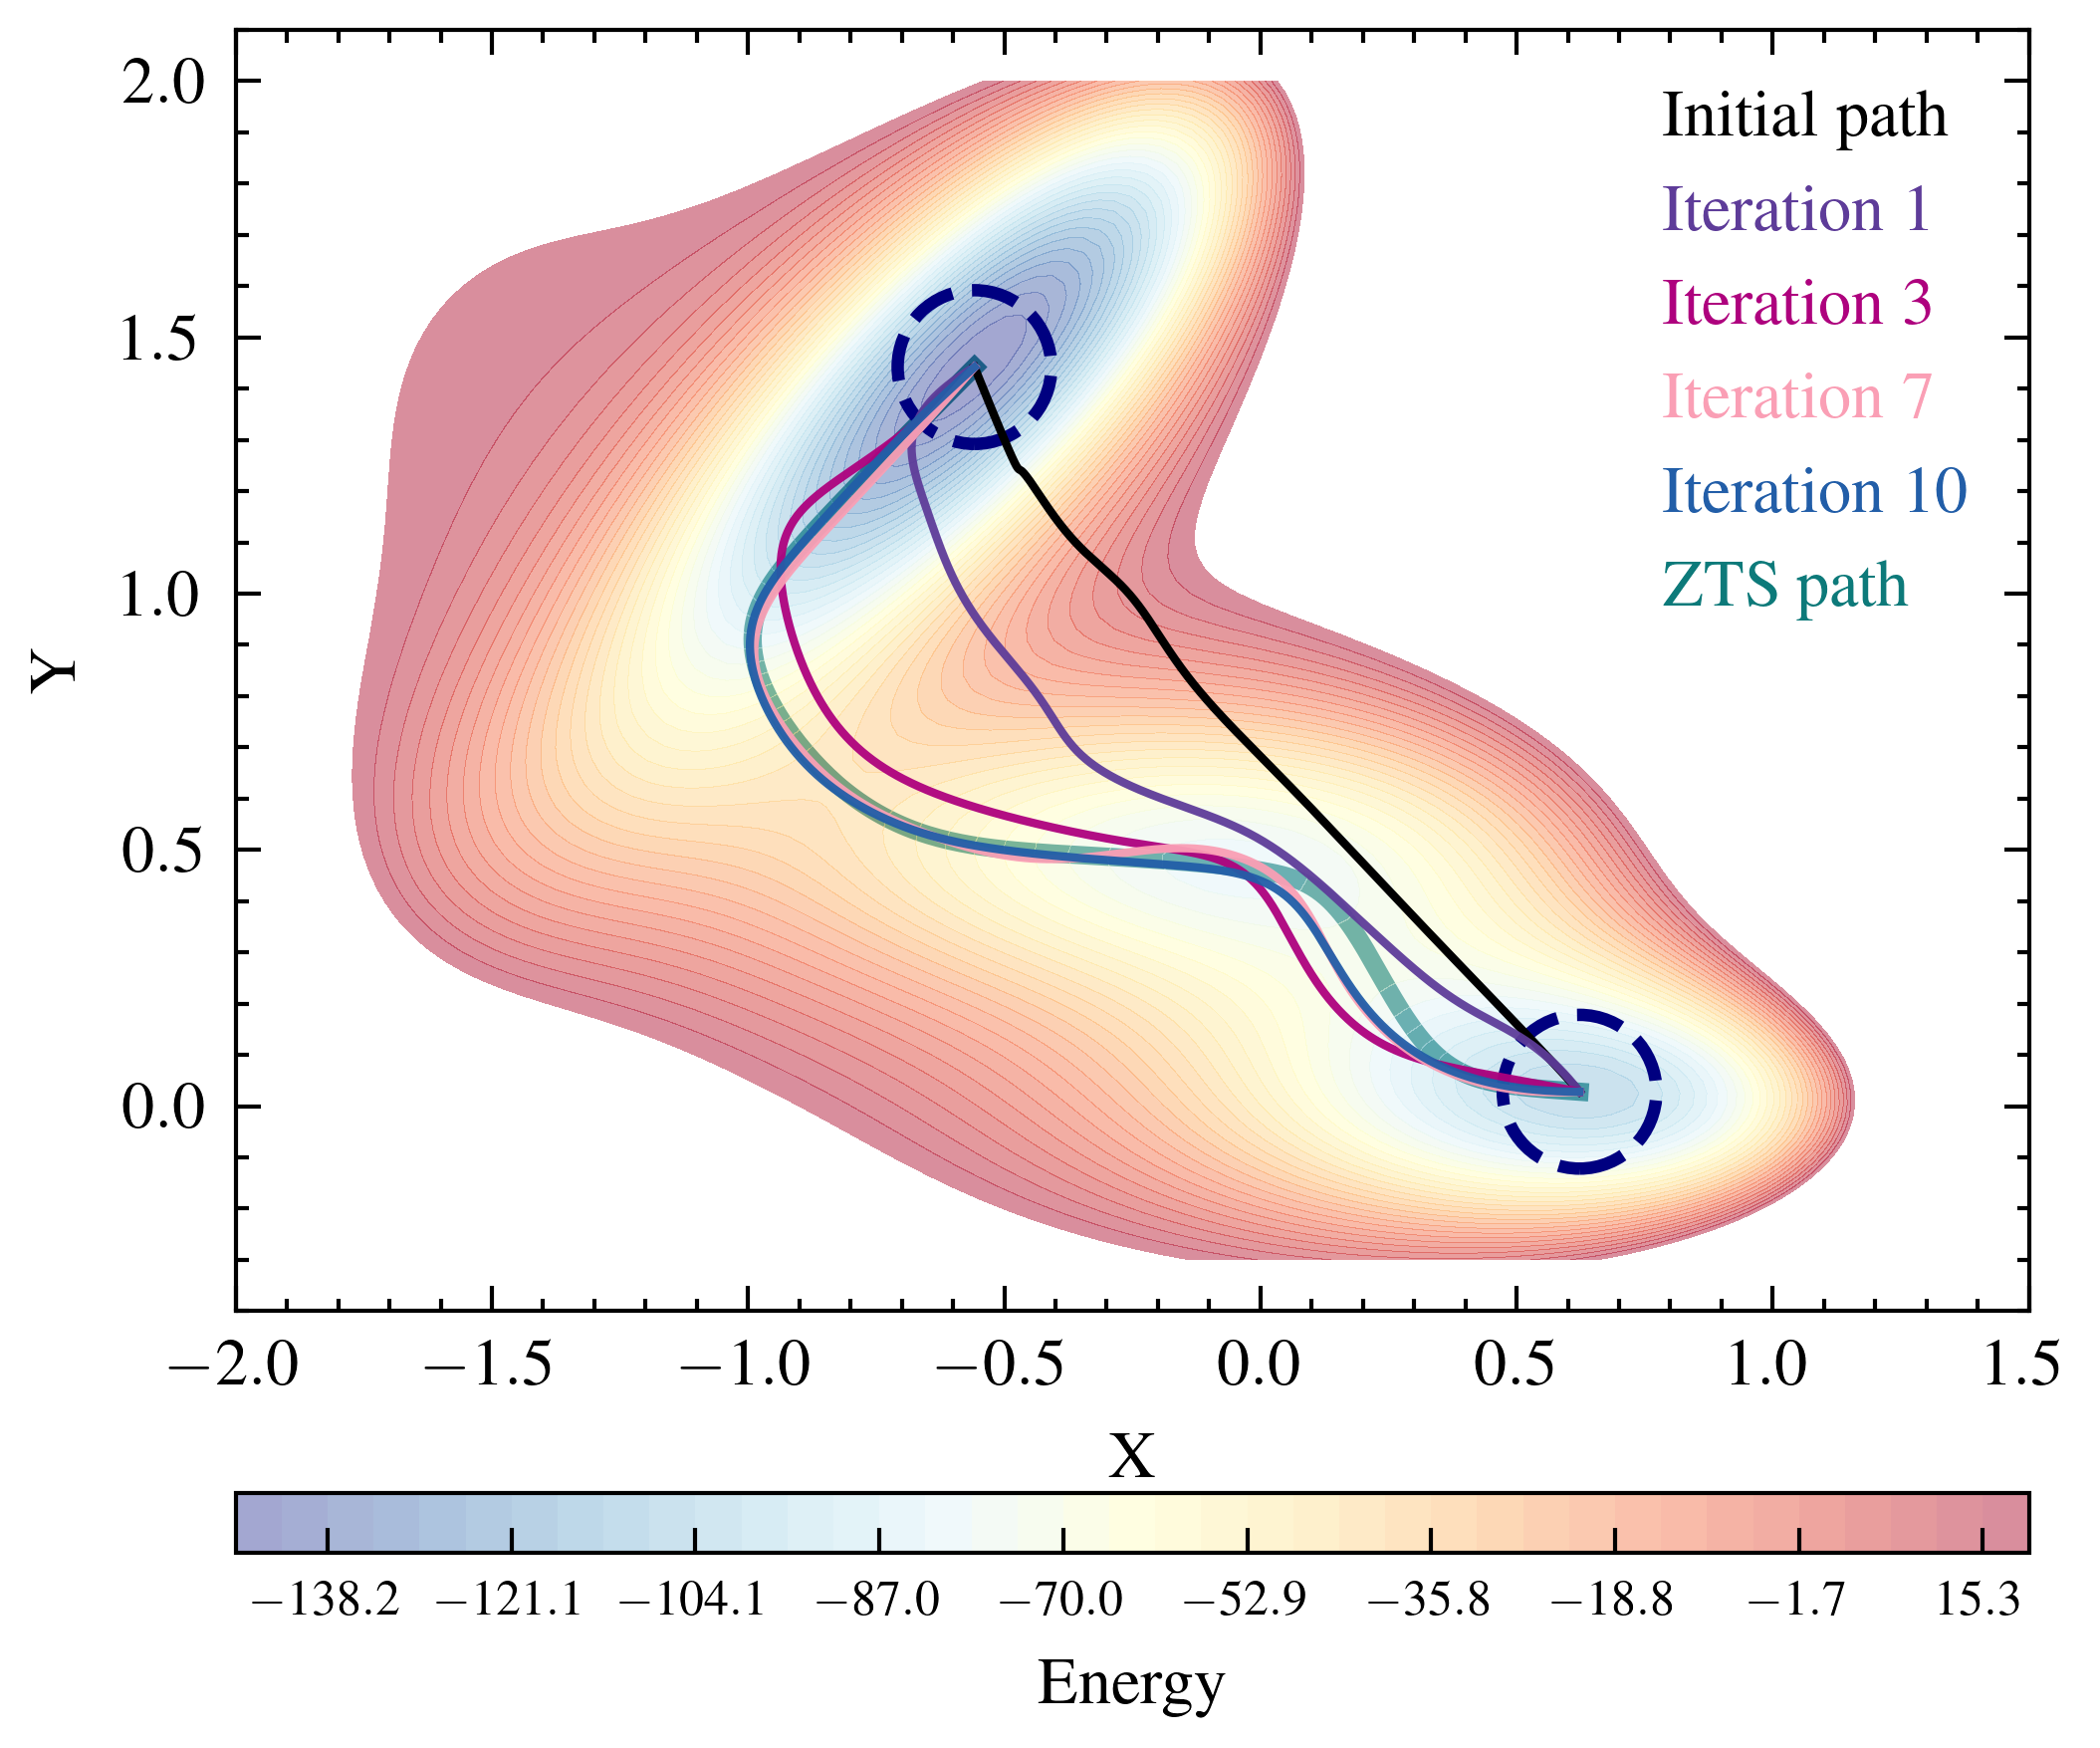

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
fig, ax = plt.subplots(figsize=(3.5, 3), constrained_layout=True)

# 1. Background Potential Energy Surface (PES)
x = np.linspace(-1.8, 1.2, 100)
y = np.linspace(-0.3, 2.0, 100)
X, Y = np.meshgrid(x, y)
Z = mb.get_energy(X, Y)
vmin, vmax = np.percentile(Z, [0, 60])

# Cleaned up contour levels and transparency
m = ax.contourf(X, Y, Z, levels=np.linspace(vmin, vmax, 40), cmap='RdYlBu_r', alpha=0.45)

# 2. Plot the basin boundaries
basin_A = plt.Circle((-0.558, 1.442), 0.15, color='navy', fill=False, linestyle='--', lw=1.5)
basin_B = plt.Circle((0.623, 0.028), 0.15, color='navy', fill=False, linestyle='--', lw=1.5)
ax.add_patch(basin_A)
ax.add_patch(basin_B)

# 3. Plot Paths (Using a color gradient for iterations to avoid messy legends)
lines = []
line, = ax.plot(initial_rep[:, :, 0], initial_rep[:, :, 1], c="black", lw=1, zorder=3, label="Initial path")
lines.append(line)

num_iterations = len(learned_rep)
# Using a colormap to represent optimization progress smoothly
colors = plt.cm.plasma(np.linspace(0.2, 0.9, num_iterations))

from matplotlib.colors import LinearSegmentedColormap

# Smooth custom progression
iter_colors = [
    "#5e3c99",  # deep purple
    "#7b3294",
    "#ae017e",
    "#dd3497",
    "#f768a1",
    "#fa9fb5",
    "#fd8d3c",
    "#f16913",
    "#d94801",
    "#225ea8",  # final blue
]

for i, rep in enumerate(learned_rep):

    if i == 0:
        label = "Iteration 1"
    elif i == num_iterations - 1:
        label = f"Iteration {num_iterations}"
    elif i == num_iterations // 2:
        label = f"Iteration {i+2}"
    elif i == 2:
        label = f"Iteration {i+1}"
    else:
        label = None
    if label is None:
        continue  # Skip plotting intermediate iterations in the legend
        # print(f"Plotting {label} with color {iter_colors[min(i, len(iter_colors)-1)]}")
    else:
        line, = ax.plot(
            rep[:, :, 0],
            rep[:, :, 1],
            color=iter_colors[min(i, len(iter_colors)-1)],
            lw=1.0,
            alpha=0.95,
            ls = "-",
            zorder=3,
            label=label,
        )
        lines.append(line)

line, = ax.plot(
    zts_path[:, 0],
    zts_path[:, 1],
    color="#0d7a7a",
    lw=2.2,
    linestyle='-',
    label="ZTS path",
    zorder=0
)
lines.append(line)
# Aspect ratio and limits
ax.set_aspect('equal', 'box')
ax.set_xlim(-2.0, 1.5)
ax.set_ylim(-0.4, 2.1)
ax.set_xlabel("X")
ax.set_ylabel("Y")

# # 4. Clean Legend Positioning (Outside the plot)
# ax.legend(loc='upper left', bbox_to_anchor=(0.68, 0.95), borderaxespad=0, frameon=False)

# 5. Horizontal Colorbar at the bottom
cbar = fig.colorbar(m, ax=ax, orientation='horizontal', pad=0.0, aspect=30)
cbar.set_label('Energy', weight='bold',)
cbar.ax.tick_params(labelsize=6)

leg = ax.legend(
    ncols=1,
    fontsize=8,
    frameon=False,
    handlelength=0,
    handletextpad=0.35,
    columnspacing=1.0,
    # loc='upper left'
)
# Hide legend handles
for handle in leg.legend_handles:
    handle.set_visible(False)

# Color legend text
for txt, line in zip(leg.get_texts(), lines):
    txt.set_color(line.get_color())
plt.show()

In [23]:
import similaritymeasures
distances = []
distances.append(similaritymeasures.frechet_dist(learned_rep[0].reshape(-1, 2), initial_rep.reshape(-1, 2)))

for i in range(len(learned_rep)-1):
    frechet_dist = similaritymeasures.frechet_dist(learned_rep[i].reshape(-1, 2), learned_rep[i+1].reshape(-1, 2))
    distances.append(frechet_dist)

In [24]:
mean_dev = []
for j in range(10):
    smooth_paths = [pc.fit(ensembles_list[j][i]) for i in range(len(ensembles_list[j]))]
    mean_dev.append(np.mean([similaritymeasures.frechet_dist(learned_rep[j].reshape(-1, 2), smooth_paths[i].reshape(-1, 2)) for i in range(len(smooth_paths))]))

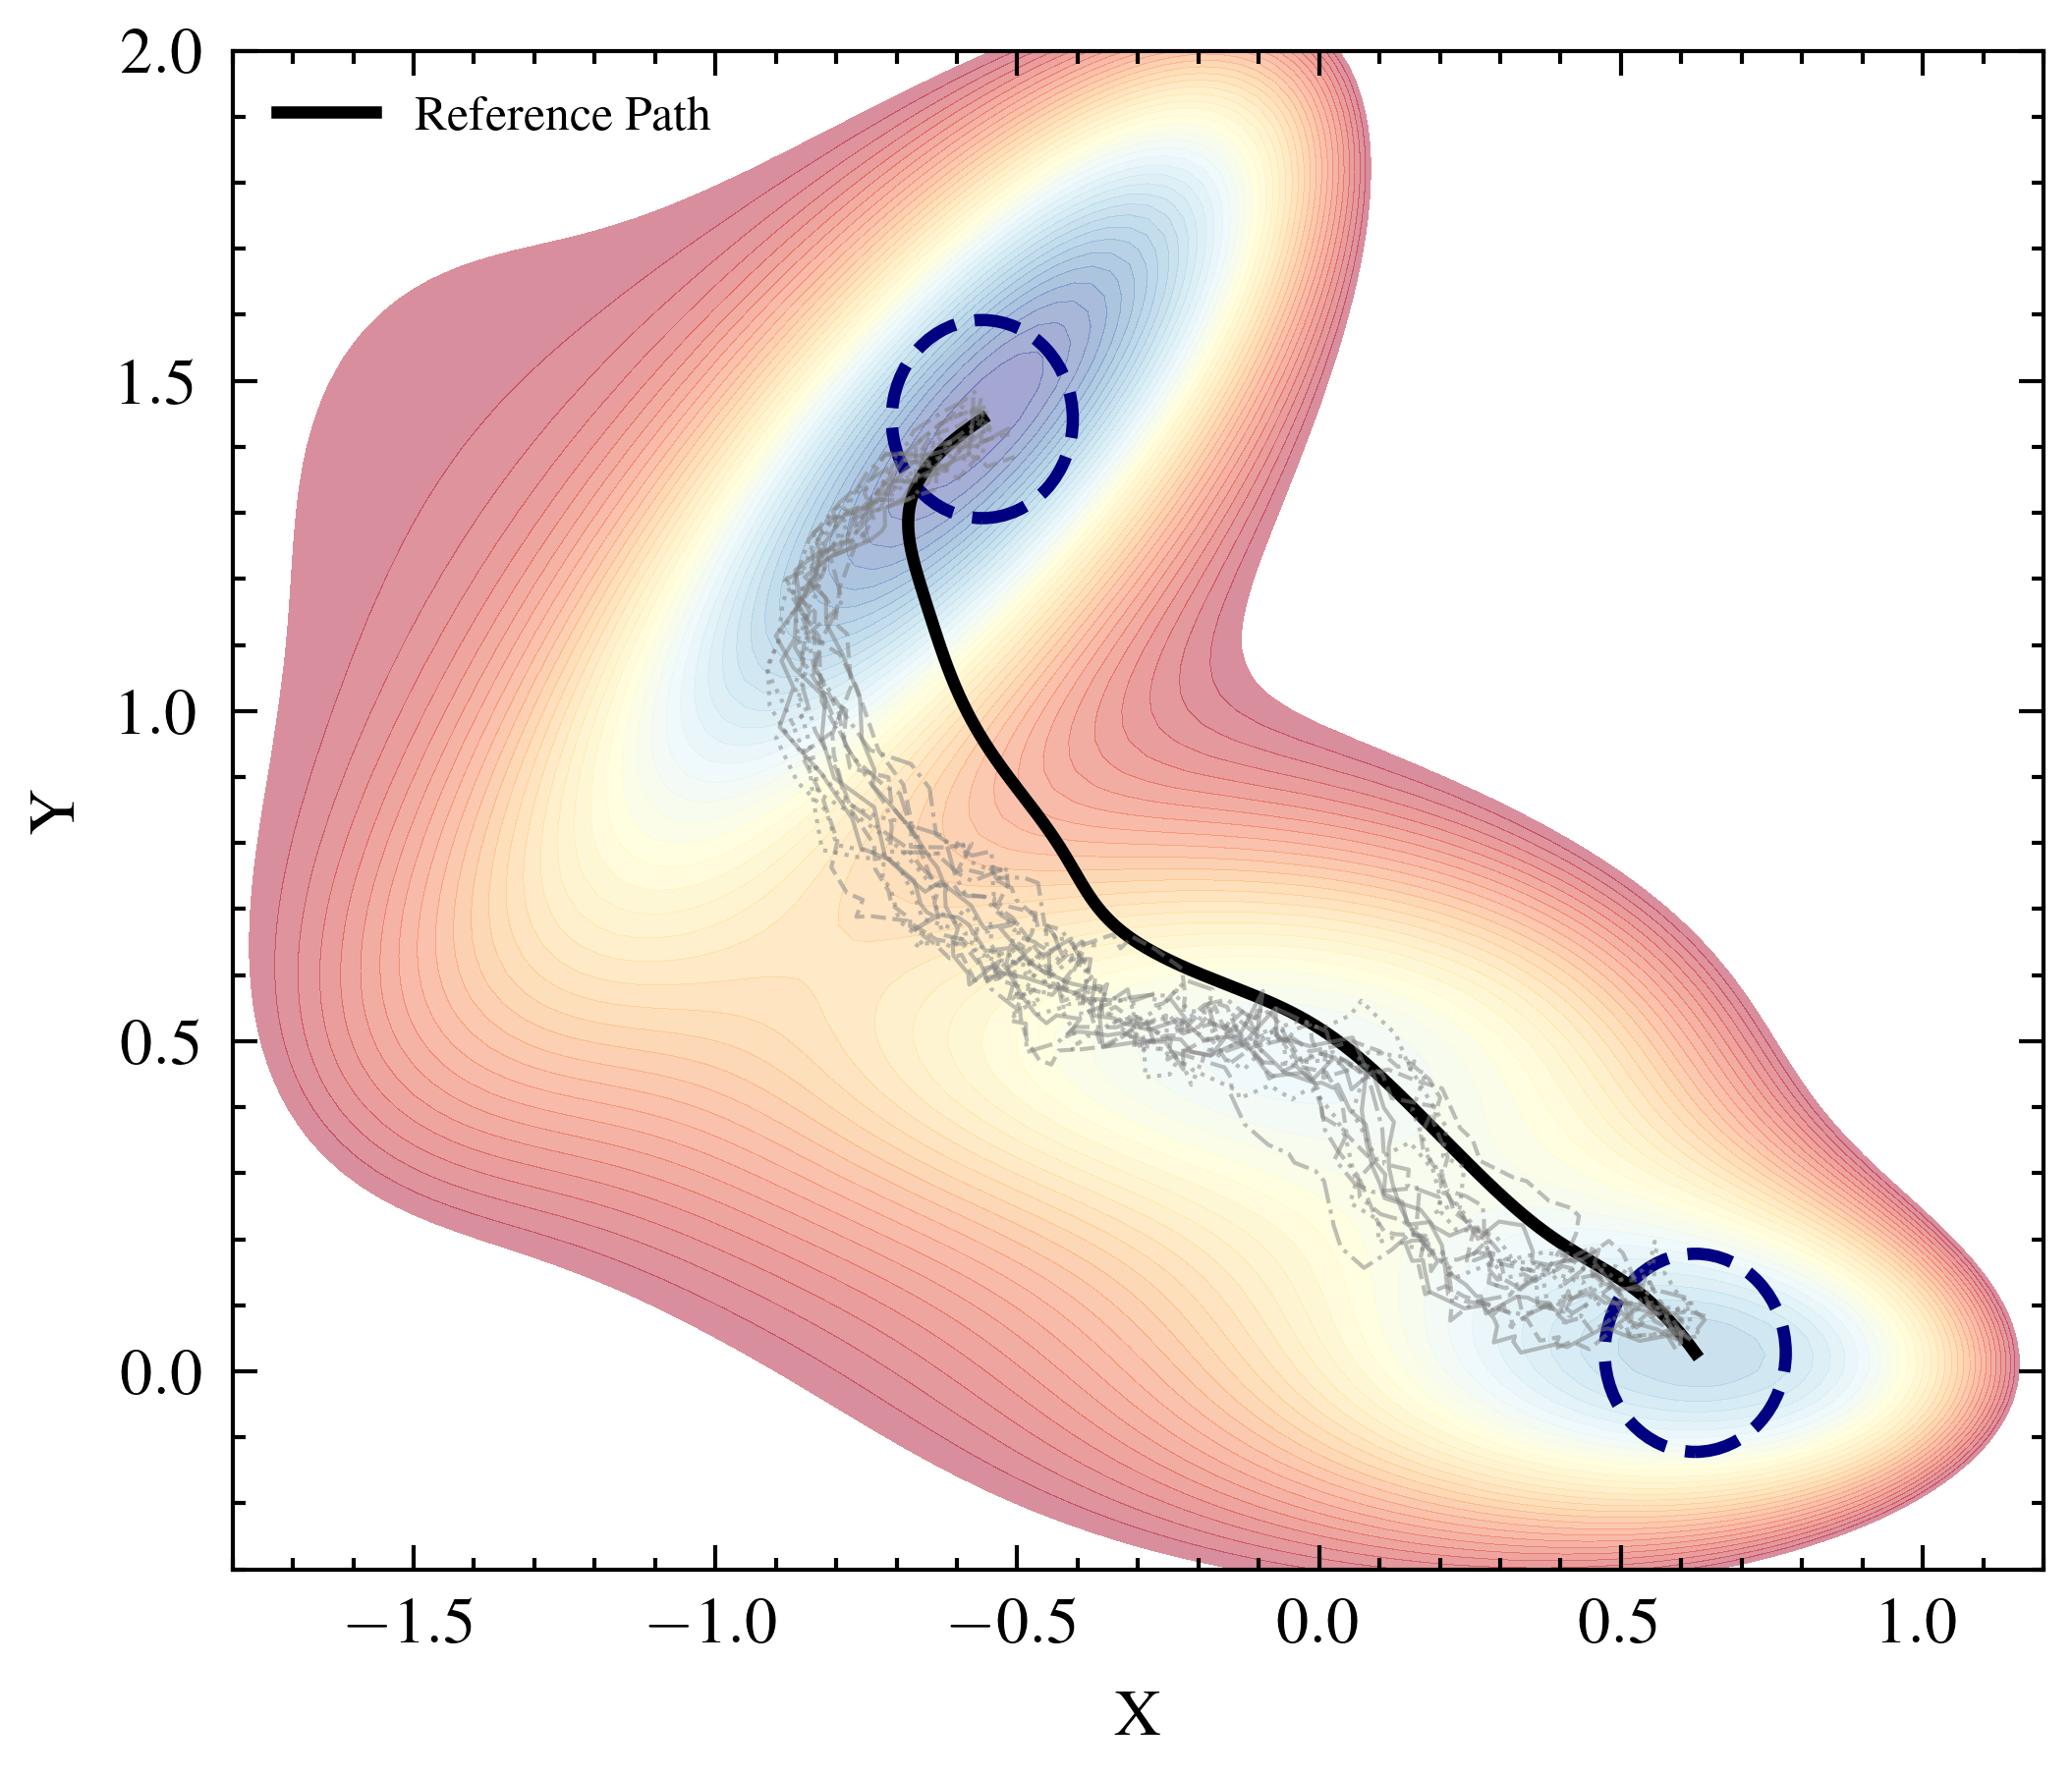

In [36]:

# fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
fig, ax = plt.subplots(figsize=(3.5, 3), constrained_layout=True)

# 1. Background Potential Energy Surface (PES)
x = np.linspace(-1.8, 1.2, 100)
y = np.linspace(-0.3, 2.0, 100)
X, Y = np.meshgrid(x, y)
Z = mb.get_energy(X, Y)
vmin, vmax = np.percentile(Z, [0, 60])

# Cleaned up contour levels and transparency
m = ax.contourf(X, Y, Z, levels=np.linspace(vmin, vmax, 40), cmap='RdYlBu_r', alpha=0.45)

# 2. Plot the basin boundaries
basin_A = plt.Circle((-0.558, 1.442), 0.15, color='navy', fill=False, linestyle='--', lw=1.5)
basin_B = plt.Circle((0.623, 0.028), 0.15, color='navy', fill=False, linestyle='--', lw=1.5)
ax.add_patch(basin_A)
ax.add_patch(basin_B)
plt.plot(learned_rep[0].reshape(-1, 2)[:, 0], learned_rep[0].reshape(-1, 2)[:, 1], label="Reference Path", color='black', lw=1.5)
for ens in ensembles_list[1]:
    plt.plot(ens[:, 0], ens[:, 1], color='gray', lw=0.5, alpha=0.5)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend(loc='upper left', fontsize=6, frameon=False)
plt.savefig("MB_Refined.pdf", dpi=300)

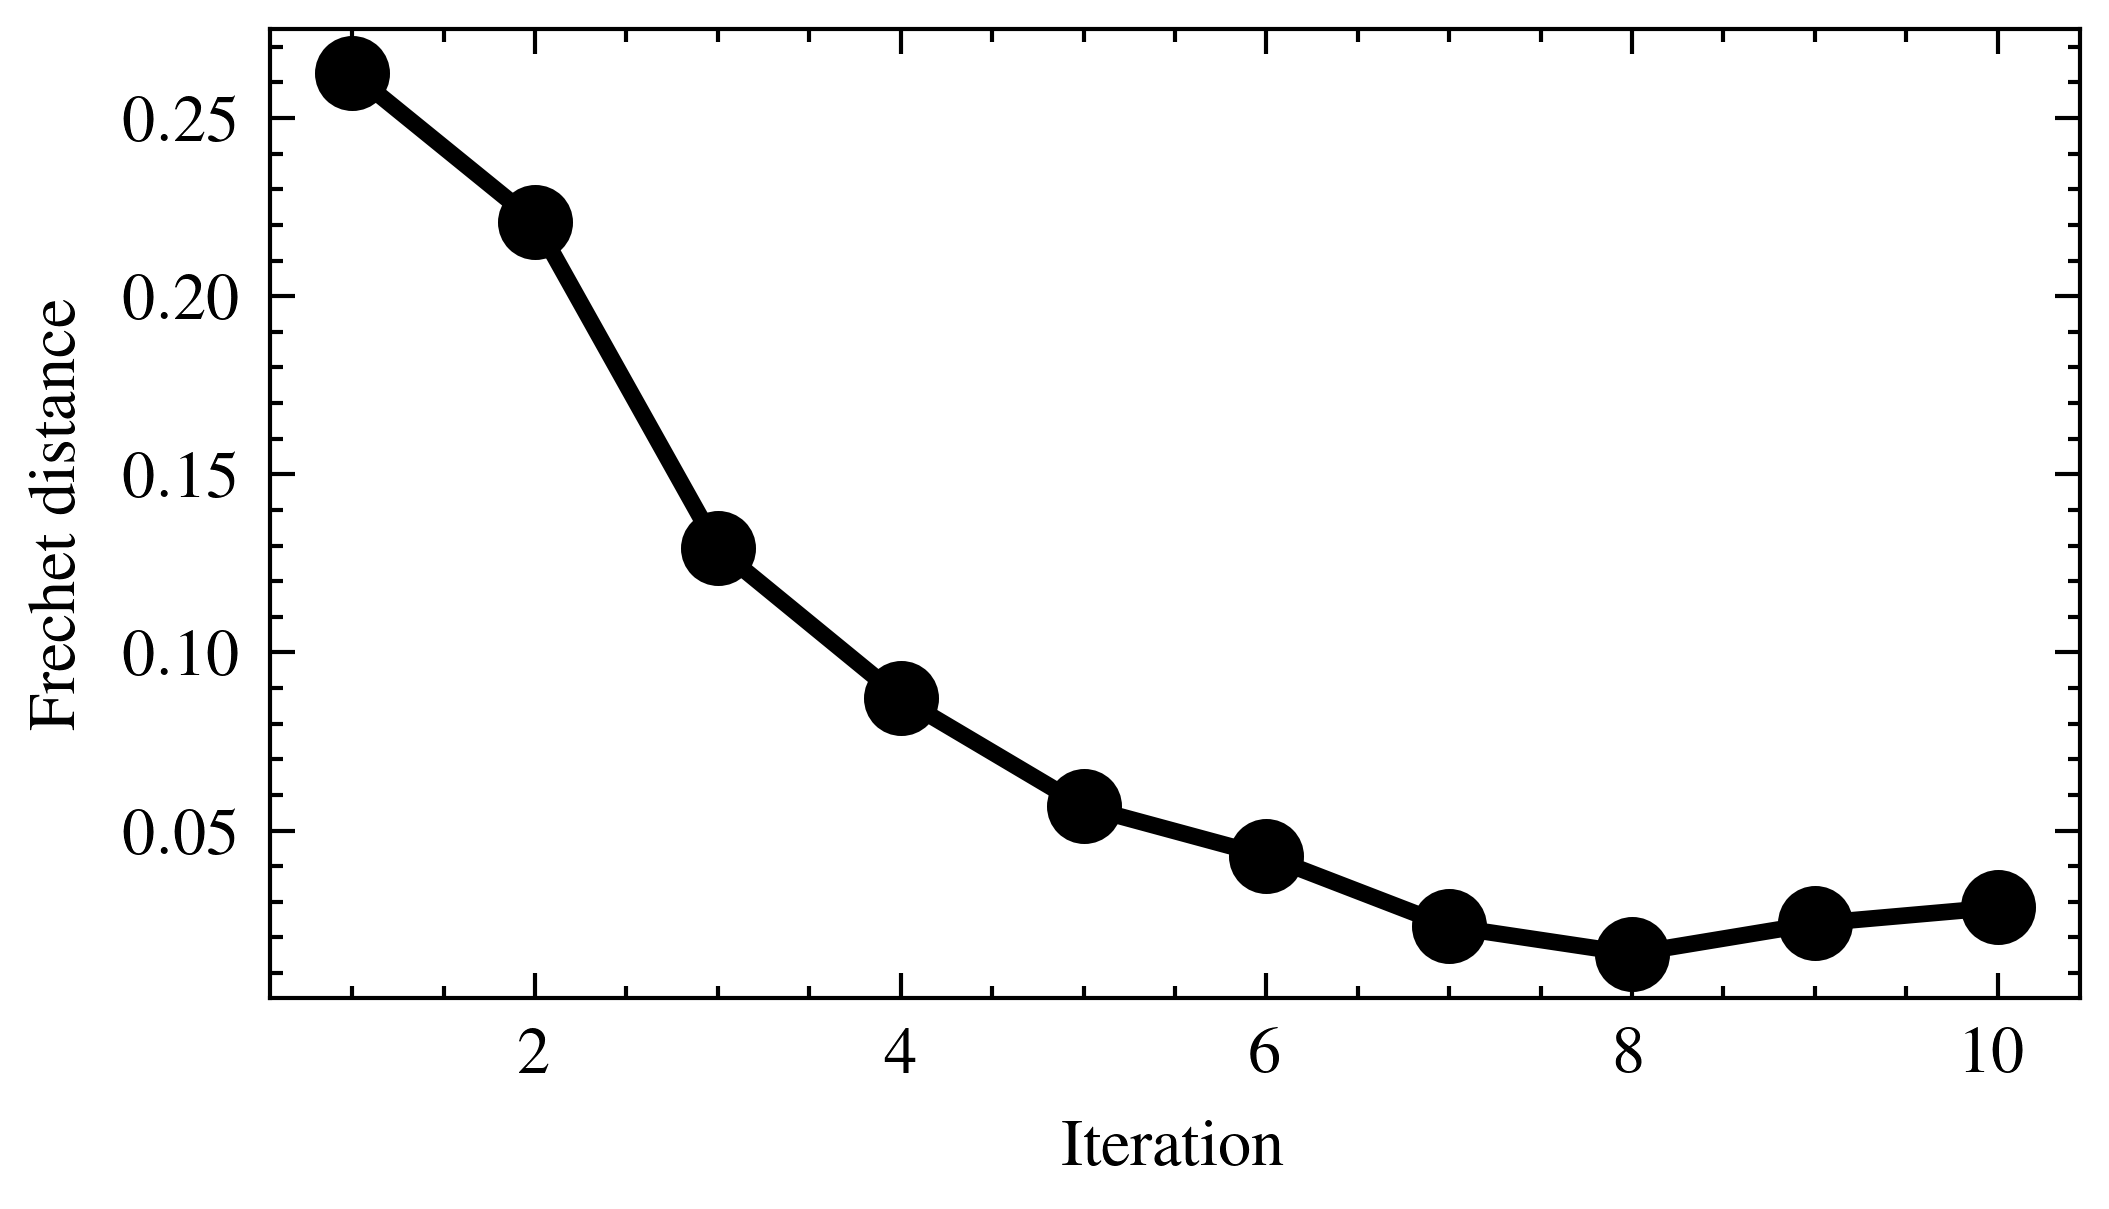

In [27]:
fig, ax1 = plt.subplots(figsize=(3.5, 2.0), constrained_layout=True)

iters = np.arange(1, len(distances) + 1)

# Left axis
l1 = ax1.plot(
    iters,
    distances,
    color='black',
    marker='o',
    lw=2,
    ms=8,
    label='Distance'
)

ax1.set_xlabel("Iteration")
ax1.set_ylabel("Frechet distance", color='black')
ax1.tick_params(axis='y', colors='black')

# Second y-axis
# ax2 = ax1.twinx()
# iters = np.arange(1, len(mean_dev) + 1)

# l2 = ax2.plot(
#     iters,
#     mean_dev,
#     color='red',
#     marker='o',
#     lw=2,
#     ls='--',
#     ms=8,
#     label='Deviation'
# )

# ax2.set_ylabel("Mean deviation", color='red')
# ax2.tick_params(axis='y', colors='red')

# Combined legend
# lines = l1 + l2
# labels = [l.get_label() for l in lines]
# ax1.legend(lines, labels, loc='upper right', frameon=False)

plt.show()